In [109]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, LeakyReLU

In [110]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [111]:
X_train.shape # 3d array

(60000, 28, 28)

In [112]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [113]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

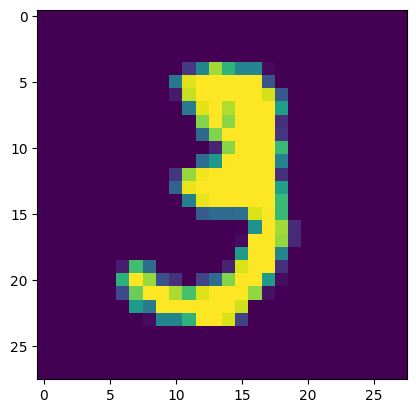

In [114]:
import matplotlib.pyplot as plt
plt.imshow(X_train[10])

In [115]:
## Make all value in the range of 0 and 1
X_train = X_train/255
X_test = X_test/255

In [116]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [117]:
model = Sequential([
    Input(shape=(28, 28)),
    # 28 × 28 → 784
    Flatten(),
    Dense(128),
    LeakyReLU(negative_slope=0.01),
    Dense(38),
    LeakyReLU(negative_slope=0.01),
    # 10 classes → 10 probabilities
    Dense(10, activation="softmax")
])

In [118]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 38)             │         4,902 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,772 (413.17 KB)

 Trainable params: 105,772 (413.17 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# 784 * 128 + 128 bias = 100480
# 128 * 10 + 1210 128 --> hidden layer

In [120]:
 model.compile(optimizer = "AdaDelta",loss = "sparse_categorical_crossentropy",metrics=["accuracy"]) # improving Adam to AdaDelta
 # sparse_categorical_crossentropy --> ismay huma one hot encoding nahi kerna padta hai
 # insted of categorical_crossentropy isko use kerta tho mujha onehot encoding kerna padta

In [121]:
# automatically decide how many time epochs will be run
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1843 - loss: 2.2900 - val_accuracy: 0.2266 - val_loss: 2.2449
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2686 - loss: 2.1993 - val_accuracy: 0.3037 - val_loss: 2.1540
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3347 - loss: 2.1104 - val_accuracy: 0.3666 - val_loss: 2.0638
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3892 - loss: 2.0210 - val_accuracy: 0.4201 - val_loss: 1.9719
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4438 - loss: 1.9305 - val_accuracy: 0.4739 - val_loss: 1.8801
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4933 - loss: 1.8409 - val_accuracy: 0.5206 - val_loss: 1.7899
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5369 - loss: 1.7537 - val_accuracy: 0.5621 - val_loss: 1.7027
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5731 - loss: 1

In [122]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [123]:
y_pred = y_prob.argmax(axis=1)

In [124]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.914

### old accuracy = 0.9751 by relu
## new accuracy = 91 by leakyrelu

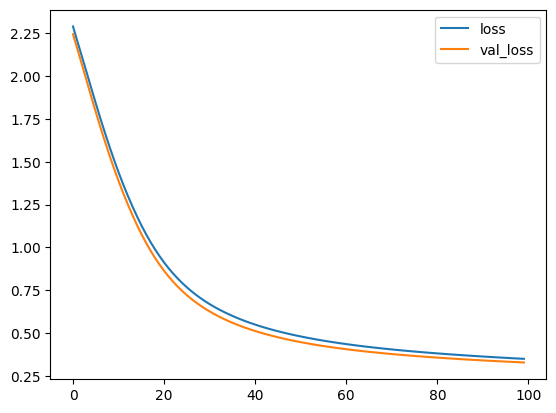

In [125]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'])
plt.show()

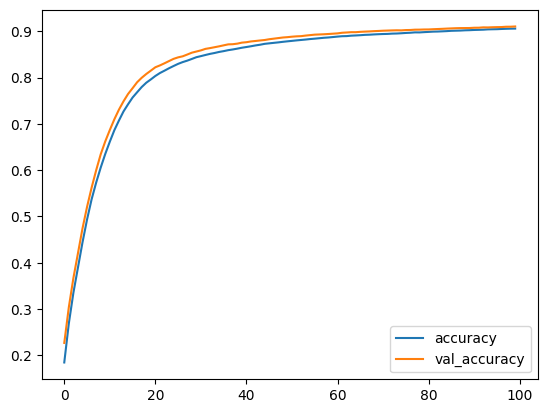

In [126]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'])
plt.show()

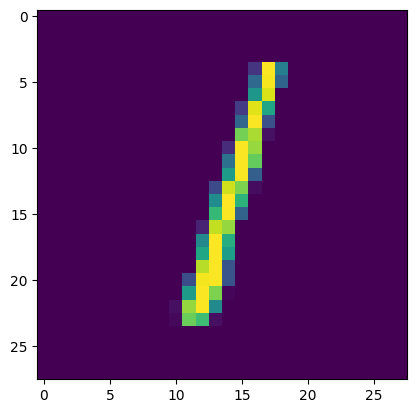

In [127]:
plt.imshow(X_test[2])

In [128]:
model.predict(X_test[2].reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[3.7580854e-04, 9.1909140e-01, 2.9639002e-02, 1.2969333e-02,
        3.0141636e-03, 3.7844193e-03, 6.9002490e-03, 6.4705573e-03,
        1.4873215e-02, 2.8817798e-03]], dtype=float32)

In [129]:
model.predict(X_test[2].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([1])